In [ ]:
from CUORETopology import TopologyAnalysis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.transforms import Affine2D

/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:19: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  self.dataframe = pd.read_csv(config['DataFile'], sep = ',', header=0)
/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

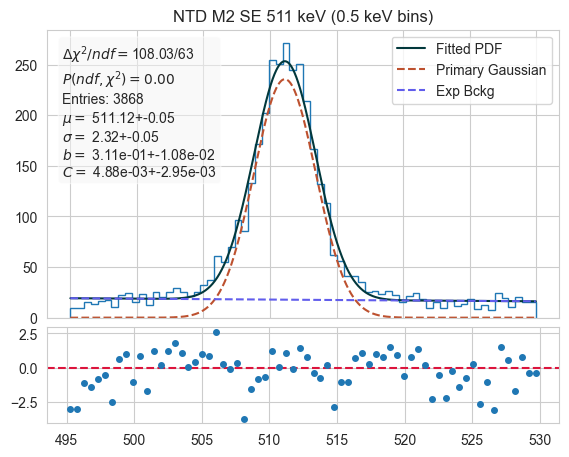

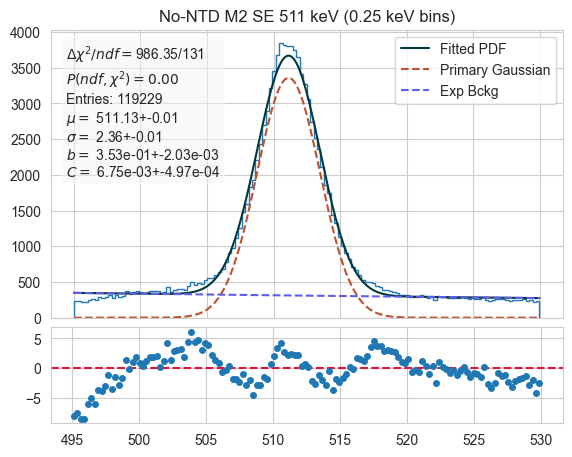

In [39]:
config = {"DataFile":'NTDs_2590_2625_q_tree_call-2tonne.csv',
          "Multiplicity": 2, 
          "EnergyRange": [2080, 2120],
          "InvalidChannels": 'InvalidChannels/M2SE511_InvalidChannelList.csv', 
          "DatasetBias": 'Dataset-Info-ResBias/M2SE511_bias_all.txt',
          "DatasetRes": 'Dataset-Info-ResBias/M2SE511_reso_all.txt',
          "EnergyDist": 511}

M2SE511Sort = TopologyAnalysis(config)

singleEscape = M2SE511Sort.SingleEscapeSort()
reducedSingleEscape = M2SE511Sort.ChannelRemoval(singleEscape)

NTDEvents, noNTDEvents = M2SE511Sort.NTD_Sort(reducedSingleEscape)

Face, Edge, Corner, NoNe= M2SE511Sort.M2Topology_Sort(noNTDEvents)

NTDEvents_2100, NTDEvents_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(NTDEvents)
noNTD_2100, noNTD_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(noNTDEvents)

data = [i for i in NTDEvents_511 if 495 <= i <= 530]

NTDmu, NTDmu_err, NTDsigma, NTDsigma_err, NTDchi2= M2SE511Sort.NormGuassianExpMinimizer(data, 'NTD M2 SE 511 keV (0.5 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 2*int(max(data) - min(data)))

dataNoNTD = [i for i in noNTD_511 if 495 <= i <= 530]

nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigma_err, nonNTDchi2= M2SE511Sort.NormGuassianExpMinimizer(dataNoNTD, 'No-NTD M2 SE 511 keV (0.25 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 4*int(max(dataNoNTD) - min(dataNoNTD)))

F_2100, F_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(Face)
C_2100, C_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(Corner)
N_2100, N_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(NoNe)
E_2100, E_511 = M2SE511Sort.PrimarySecondarySplitSingleEscape(Edge)

F_511_cut = [i for i in F_511 if 495 <= i <= 530]
C_511_cut = [i for i in C_511 if 495 <= i <= 530]
N_511_cut = [i for i in N_511 if 495 <= i <= 530]
E_511_cut = [i for i in E_511 if 495 <= i <= 530]

arr=[F_511_cut, C_511_cut, N_511_cut, E_511_cut]

topologies = ['F', 'C', 'N', 'E']

Fintial =  [511, 2.3, 0.11, 6.89713150e-03]
Cinitial =  [511, 2.3, 0.11, 6.89713150e-03]
Ninitial = [511, 2.3, 0.11, 6.89713150e-03]
Eintial =  [511, 2.3, 0.11, 6.89713150e-03]

initial_parms = [Fintial, Cinitial, Ninitial, Eintial]

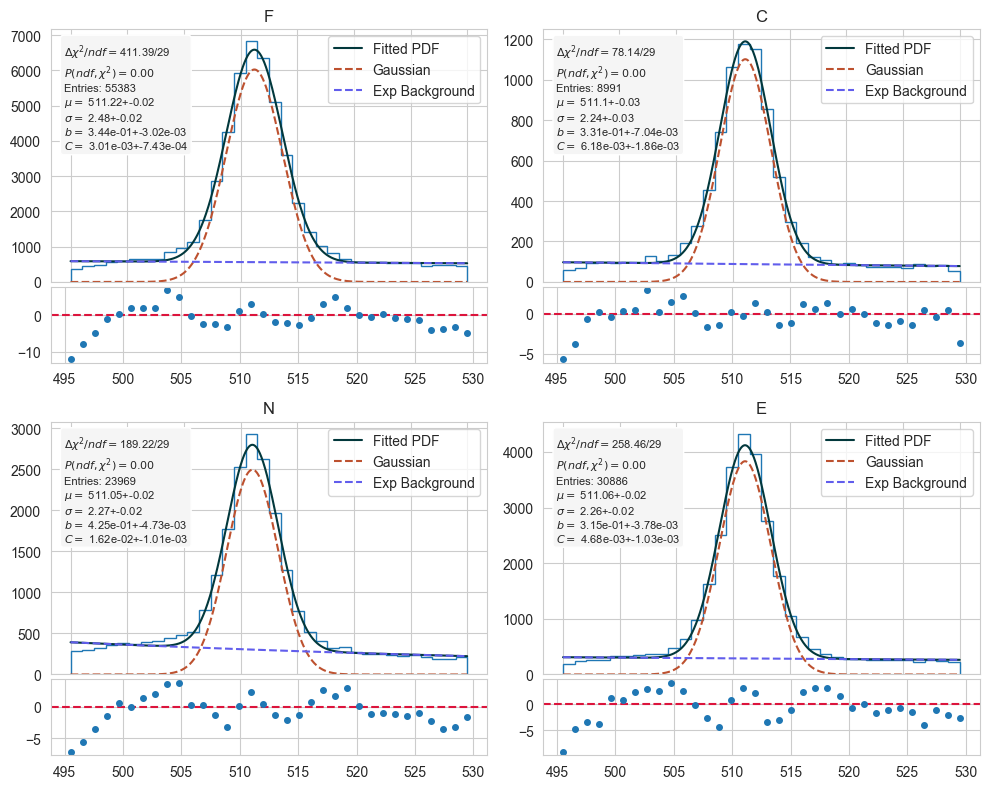

In [40]:
df = M2SE511Sort.NormGaussianExpMinimizerTopology(arr, topologies, initial_parms, 2,2, 10, 8)

Text(0.5, 1.0, 'Overlapping Maximum Bias Topology Plots M2 SE 511 keV')

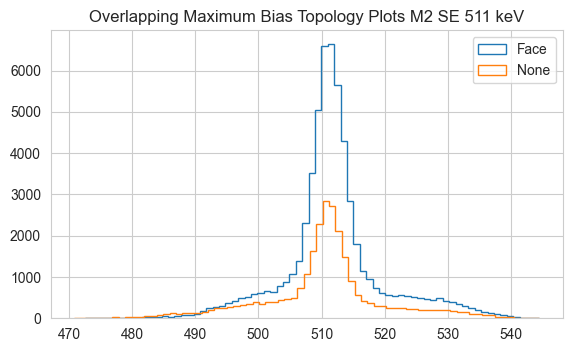

In [13]:
fig = plt.figure()
ax=fig.add_axes((.1,.3,.8,.6))

ax.hist(F_511, bins = int(max(F_511) - min(F_511)) , histtype='step', label='Face');
ax.hist(N_511, bins = int(max(N_511) - min(N_511)) , histtype='step', label='None');

ax.legend(loc='upper right')
ax.set_title("Overlapping Maximum Bias Topology Plots M2 SE 511 keV")

In [41]:
mean_bias, sigma, meanerr, sigmaerr = M2SE511Sort.ExpectedVals(reducedSingleEscape, reducedSingleEscape)

In [16]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

In [15]:
predictions = df['Sigmas']
expected = [nonNTDsigma] * len(predictions)
rmse(predictions, expected)

NameError: name 'rmse' is not defined

Text(0.5, 1.0, 'M2 SE 511 keV Std. Devs')

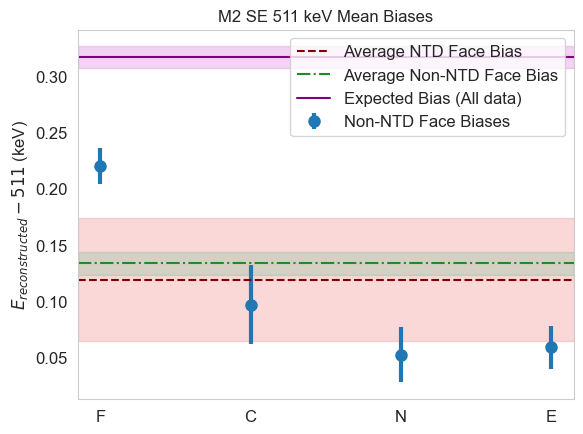

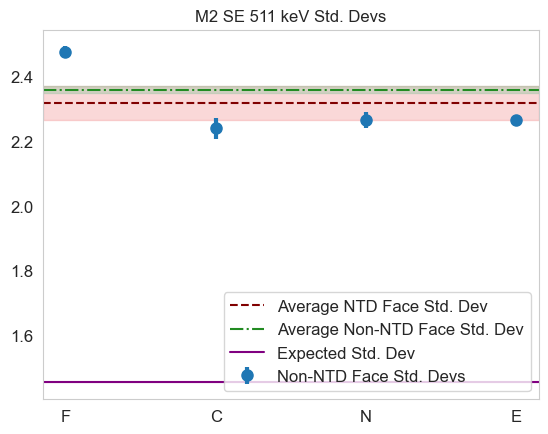

In [42]:
plt.figure()
plt.errorbar(topologies, df['Means']-511, yerr=df['Meanserr'], ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Biases')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDmu-511 - NTDmu_err, NTDmu-511 + NTDmu_err, color='lightcoral', alpha=0.3)
plt.axhline(NTDmu-511, color='maroon', linestyle='--', label='Average NTD Face Bias')

plt.axhspan(nonNTDmu-511-nonNTDmu_err, nonNTDmu-511+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDmu-511, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Bias')

plt.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
plt.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias (All data)')

plt.legend(fontsize=12)

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M2 SE 511 keV Mean Biases')
plt.ylabel(r'$E_{reconstructed}-511$ (keV)', fontsize=12)

plt.figure()
plt.errorbar(topologies, df['Sigmas'], yerr=df['Sigmaserr'], ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Std. Devs')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDsigma + NTDsigma_err, NTDsigma - NTDsigma_err, color='lightcoral', alpha=0.3)
plt.axhline(NTDsigma, color='maroon', linestyle='--', label='Average NTD Face Std. Dev')

plt.axhspan(nonNTDsigma-nonNTDsigma_err, nonNTDsigma+nonNTDsigma_err, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Std. Dev')

plt.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
plt.axhline(sigma, color='purple', linestyle='-', label='Expected Std. Dev')

plt.legend(fontsize=12,loc='lower right')

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M2 SE 511 keV Std. Devs')

In [31]:
config = {"DataFile":'NTDs_2590_2625_q_tree_call-2tonne.csv',
          "Multiplicity": 3, 
          "EnergyRange": [2070, 2130],
          "InvalidChannels": 'InvalidChannels/M3SE511_InvalidChannelList.csv', 
          "DatasetBias": 'Dataset-Info-ResBias/M3SE511_bias_all.txt',
          "DatasetRes": 'Dataset-Info-ResBias/M3SE511_reso_all.txt',
          "EnergyDist": 511}

M3SE511Sort = TopologyAnalysis(config)

/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:19: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  self.dataframe = pd.read_csv(config['DataFile'], sep = ',', header=0)


In [32]:
M3singleEscape = M3SE511Sort.SingleEscapeSort()
M3reducedSingleEscape = M3SE511Sort.ChannelRemoval(M3singleEscape)

NTDEvents, noNTDEvents = M3SE511Sort.NTD_Sort(M3reducedSingleEscape)
NonNTD_2100, NonNTD_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(noNTDEvents)

NTD_2100, NTD_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(NTDEvents)

/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:73: SettingWithCopyWarning: 
A value is trying to be set on a

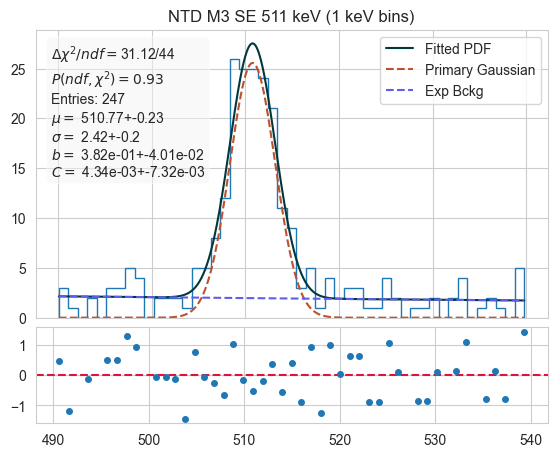

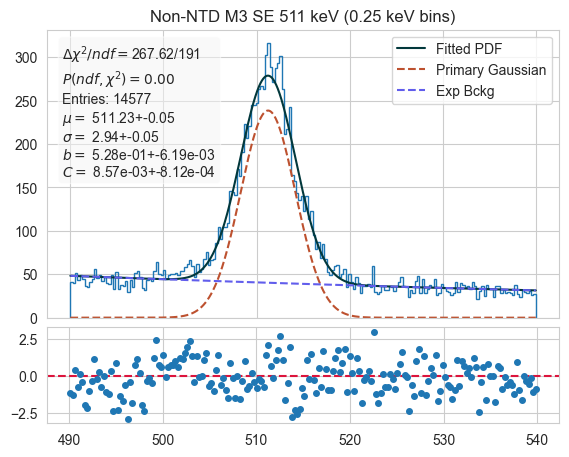

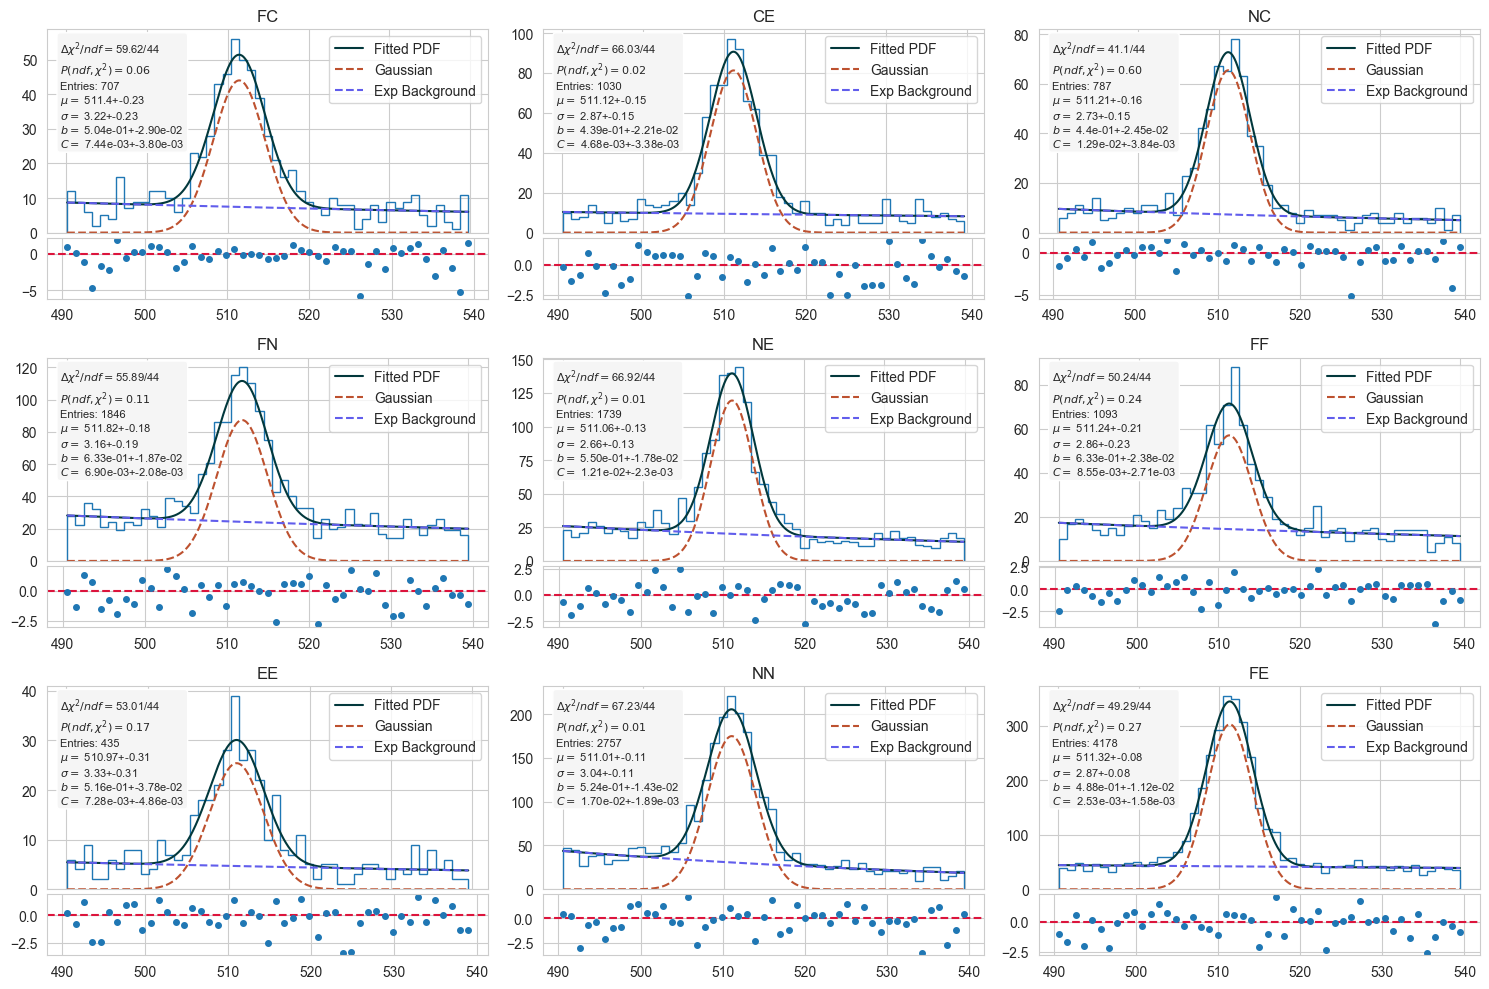

In [33]:
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = M3SE511Sort.M3Topology_Sort(NTDEvents)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = M3SE511Sort.M3Topology_Sort(noNTDEvents)

NTD_events = pd.concat([CE_NTD, NC_NTD, NE_NTD, CC_NTD, EE_NTD, NN_NTD])
NTD_2100, NTD_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(NTD_events)

NonNTDevents = pd.concat([FC, FC_NTD, CE, NC, FN, FN_NTD, NE, FF, FF_NTD, CC, EE, NN, FE, FE_NTD])
NonNTD_2100, NonNTD_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(NonNTDevents)

data = [i for i in NTD_511 if 490 <= i <= 540]
NTDmu, NTDmu_err, NTDsigma, NTDsigmaerr, NTDchi2 = M3SE511Sort.NormGuassianExpMinimizer(data, 'NTD M3 SE 511 keV (1 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], int(max(data)-min(data)))

dataNonNTD = [i for i in NonNTD_511 if 490 <= i <= 540]
nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigmaerr, nonNTDchi2 = M3SE511Sort.NormGuassianExpMinimizer(dataNonNTD, 'Non-NTD M3 SE 511 keV (0.25 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 4*int(max(dataNonNTD)-min(dataNonNTD)))

FCmerged = pd.concat([FC, FC_NTD])
FNmerged = pd.concat([FN, FN_NTD])
FFmerged = pd.concat([FF, FF_NTD])
FEmerged = pd.concat([FE, FE_NTD])

FC_511_cut, FC_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(FCmerged)
CE_511_cut, CE_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(CE)
NC_511_cut, NC_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(NC)
FN_511_cut, FN_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(FNmerged)
NE_511_cut, NE_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(NE)
FF_511_cut, FF_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(FFmerged)
# CC_511_cut, CC_511 = PrimarySecondarySplit(CC) not enough events to fit anything
EE_511_cut, EE_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(EE)
NN_511_cut, NN_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(NN)
FE_511_cut, FE_511 = M3SE511Sort.PrimarySecondarySplitSingleEscape(FEmerged)

FC_511_cut = [i for i in FC_511 if 490 <= i <= 540]
CE_511_cut = [i for i in CE_511 if 490 <= i <= 540]
NC_511_cut = [i for i in NC_511 if 490 <= i <= 540]
FN_511_cut = [i for i in FN_511 if 490 <= i <= 540]
NE_511_cut = [i for i in NE_511 if 490 <= i <= 540]
FF_511_cut = [i for i in FF_511 if 490 <= i <= 540]
EE_511_cut = [i for i in EE_511 if 490 <= i <= 540]
NN_511_cut = [i for i in NN_511 if 490 <= i <= 540]
FE_511_cut = [i for i in FE_511 if 490 <= i <= 540]

FC_initial_511 = [5.11200577e+02, 3.03369145e+00, 0.5, 7.55802068e-03]
CE_initial_511 = [5.11018269e+02, 2.81020118e+00, 0.5,5.87756146e-03]
NC_initial_511 = [5.11182419e+02, 2.78208147e+00, 0.5, 1.27697351e-02]
FN_initial_511 = [5.11850438e+02, 2.92269445e+00, 0.5,6.89676842e-03]
NE_initial_511 = [5.11029528e+02, 2.58916615e+00,  0.5, 1.28240231e-02]
FF_initial_511 = [5.11469486e+02, 2.69210304e+00,  0.5, 6.42837798e-03]
EE_initial_511 = [5.10857992e+02, 3.17146179e+00,  0.5, 8.35769289e-03]
NN_initial_511 = [5.10889791e+02, 2.94974151e+00,  0.5,1.63421618e-02]
FE_initial_511 = [5.11249583e+02, 2.83977420e+00, 0.5, 2.96274049e-03]

hist_data = [FC_511_cut, CE_511_cut, NC_511_cut, FN_511_cut, NE_511_cut, FF_511_cut, EE_511_cut, NN_511_cut, FE_511_cut]
initial_parms = [FC_initial_511, CE_initial_511, NC_initial_511, FN_initial_511, NE_initial_511, FF_initial_511, EE_initial_511, NN_initial_511, FE_initial_511]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

df = M3SE511Sort.NormGaussianExpMinimizerTopology(hist_data, topologies, initial_parms, 3,3, 15, 10)

In [34]:
mean_bias, sigma, meanerr, sigmaerr = M3SE511Sort.ExpectedVals(M3reducedSingleEscape, M3reducedSingleEscape)

In [38]:
predictions = df['Sigmas']
print(predictions)
expected = [nonNTDsigma] * len(predictions)
rmse(predictions, expected)

0    3.218912
1    2.865050
2    2.730511
3    3.157130
4    2.661081
5    2.860149
6    3.334514
7    3.044527
8    2.871581
Name: Sigmas, dtype: float64


np.float64(0.21931290558298533)

Text(0.5, 1.0, 'M3 SE 511 keV Std Devs')

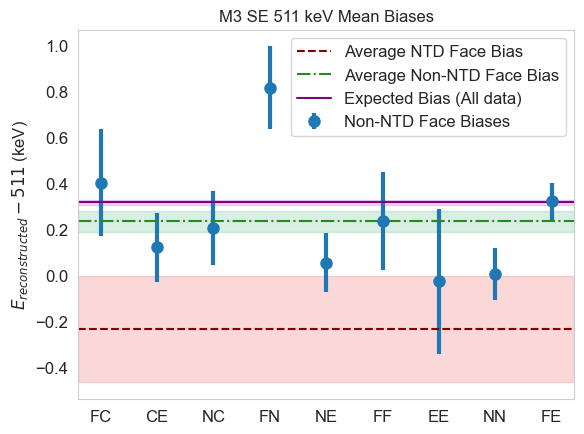

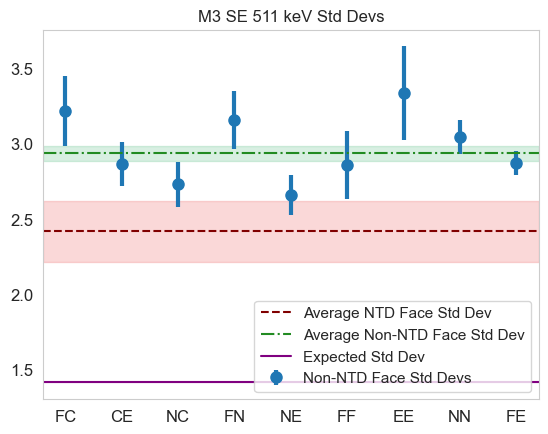

In [36]:
plt.figure()
plt.errorbar(topologies, df['Means']-511, yerr=df['Meanserr'], ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Biases')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDmu-511 - NTDmu_err, NTDmu-511 + NTDmu_err, color='lightcoral', alpha=0.3)
plt.axhline(NTDmu-511, color='maroon', linestyle='--', label='Average NTD Face Bias')

plt.axhspan(nonNTDmu-511-nonNTDmu_err, nonNTDmu-511+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDmu-511, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Bias')

plt.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
plt.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias (All data)')

plt.legend(fontsize=12)

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 SE 511 keV Mean Biases')
plt.ylabel(r'$E_{reconstructed}-511$ (keV)', fontsize=12)

plt.figure()
plt.errorbar(topologies, df['Sigmas'], yerr=df['Sigmaserr'], ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Std Devs')
# plt.errorbar(xNonNTD-0.13, topologymeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(NTDsigma + NTDsigmaerr, NTDsigma - NTDsigmaerr, color='lightcoral', alpha=0.3)
plt.axhline(NTDsigma, color='maroon', linestyle='--', label='Average NTD Face Std Dev')

plt.axhspan(nonNTDsigma-nonNTDsigmaerr, nonNTDsigma+nonNTDsigmaerr, color='mediumseagreen', alpha=0.2)
plt.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Std Dev')

plt.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
plt.axhline(sigma, color='purple', linestyle='-', label='Expected Std Dev')

plt.legend(fontsize=11,loc='lower right')

plt.xticks(np.arange(len(topologies)), topologies, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 SE 511 keV Std Devs')

In [2]:
config = {"DataFile":'NTDs_2590_2625_q_tree_call-2tonne.csv',
          "Multiplicity": 3, 
          "EnergyRange": [500, 520],
          "InvalidChannels": 'InvalidChannels/M3DE511_InvalidChannelList.csv', 
          "DatasetBias": 'Dataset-Info-ResBias/M3DE511_bias_all.txt',
          "DatasetRes": 'Dataset-Info-ResBias/M3DE511_reso_all.txt',
          "EnergyDist": 511}

M3DE511Sort = TopologyAnalysis(config)

doubleEscape = M3DE511Sort.DoubleEscapeSort()
reducedDoubleEscape = M3DE511Sort.ChannelRemoval(doubleEscape)

NTDEvents, noNTDEvents = M3DE511Sort.NTD_Sort(reducedDoubleEscape)

/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:19: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  self.dataframe = pd.read_csv(config['DataFile'], sep = ',', header=0)
/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/Users/anishayeddanapudi/Berkeley/Labs/Kolomensky Lab/CUORETopology.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [6]:
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = M3DE511Sort.M3Topology_Sort(noNTDEvents)
nonNTD_1600, nonNTD_511  = M3DE511Sort.PrimarySecondarySplitDoubleEscape(noNTDEvents)

NTD_1600, NTD_511 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(NTDEvents)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = M3DE511Sort.M3Topology_Sort(NTDEvents)

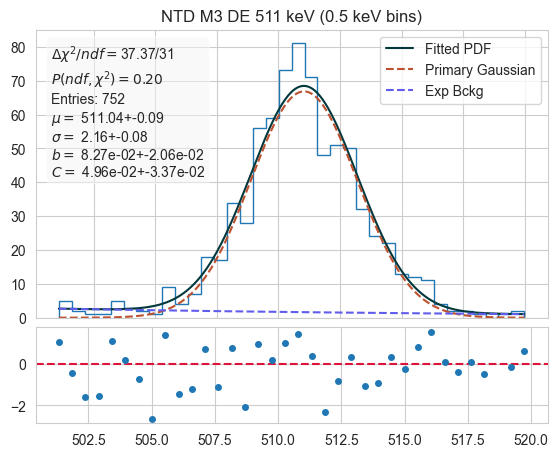

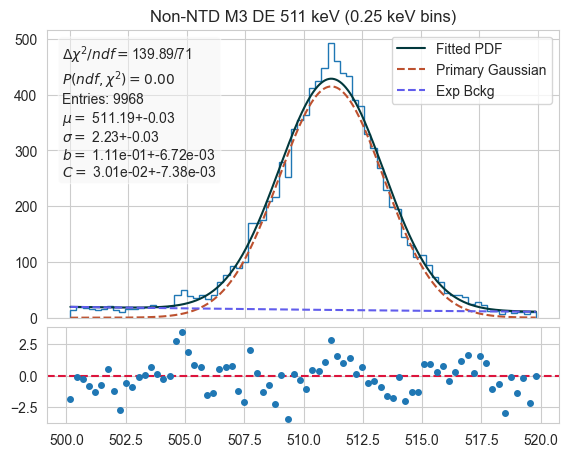

In [8]:
NTDmu, NTDmu_err, NTDsigma, NTDsigma_err, NTDchi2= M3DE511Sort.NormGuassianExpMinimizer(NTD_511, 'NTD M3 DE 511 keV (0.5 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 2*int(max(NTD_511) - min(NTD_511)))
nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigma_err, nonNTDchi2= M3DE511Sort.NormGuassianExpMinimizer(nonNTD_511, 'Non-NTD M3 DE 511 keV (0.25 keV bins)', [511, 2.3, 0.11, 6.89713150e-03], 4*int(max(nonNTD_511) - min(nonNTD_511)))

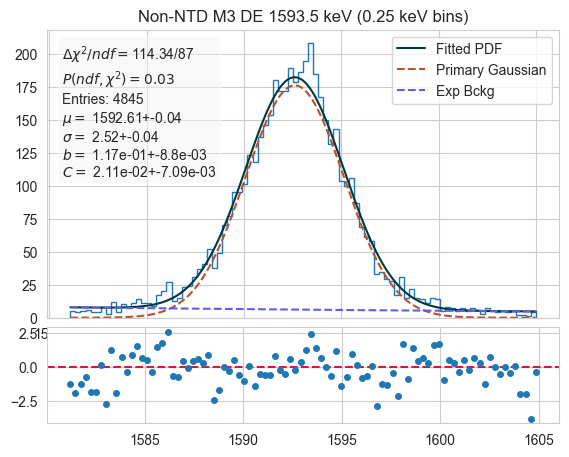

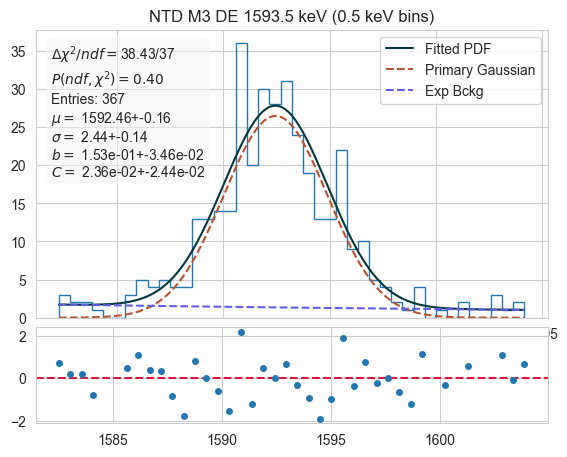

In [22]:
nonNTD_1600_cut = [i for i in nonNTD_1600 if 1581 < i < 1605]
nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigma_err, nonNTDchi2= M3DE511Sort.NormGuassianExpMinimizer(nonNTD_1600_cut, 'Non-NTD M3 DE 1593.5 keV (0.25 keV bins)', [1593, 2.3, 0.11, 6.89713150e-03], 4*int(max(nonNTD_1600_cut) - min(nonNTD_1600_cut)))

NTD_1600_cut = [i for i in NTD_1600 if 1581 < i < 1605]
NTDmu, NTDmu_err, NTDsigma, NTDsigma_err, NTDchi2= M3DE511Sort.NormGuassianExpMinimizer(NTD_1600_cut, 'NTD M3 DE 1593.5 keV (0.5 keV bins)', [1593, 2.3, 0.11, 6.89713150e-03], 2*int(max(NTD_1600_cut) - min(NTD_1600_cut)))

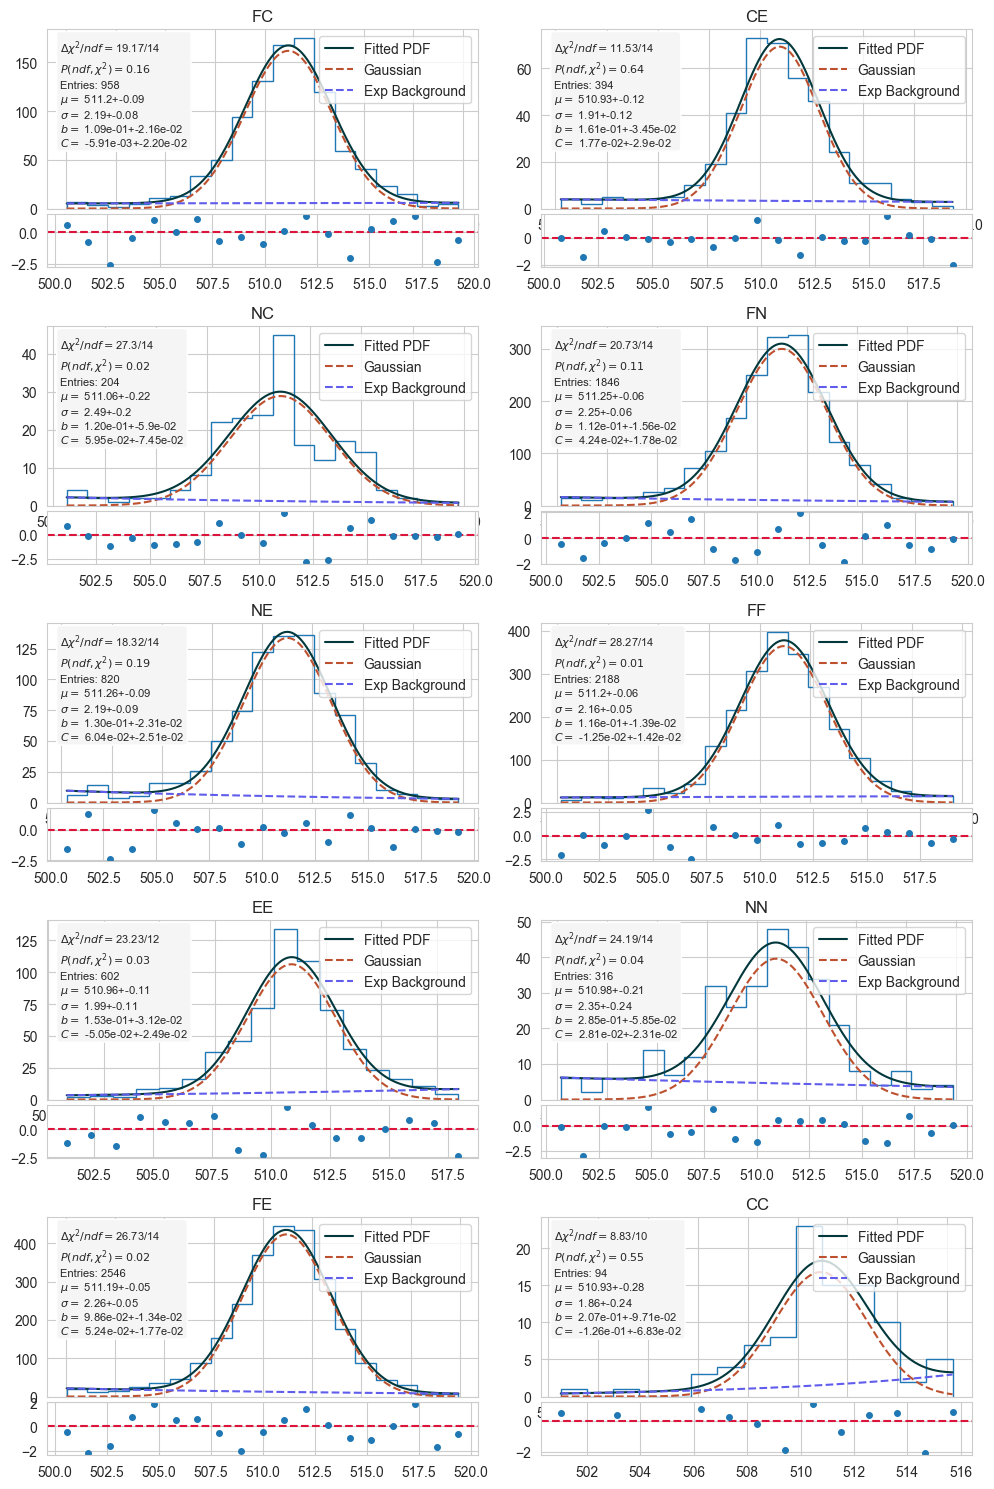

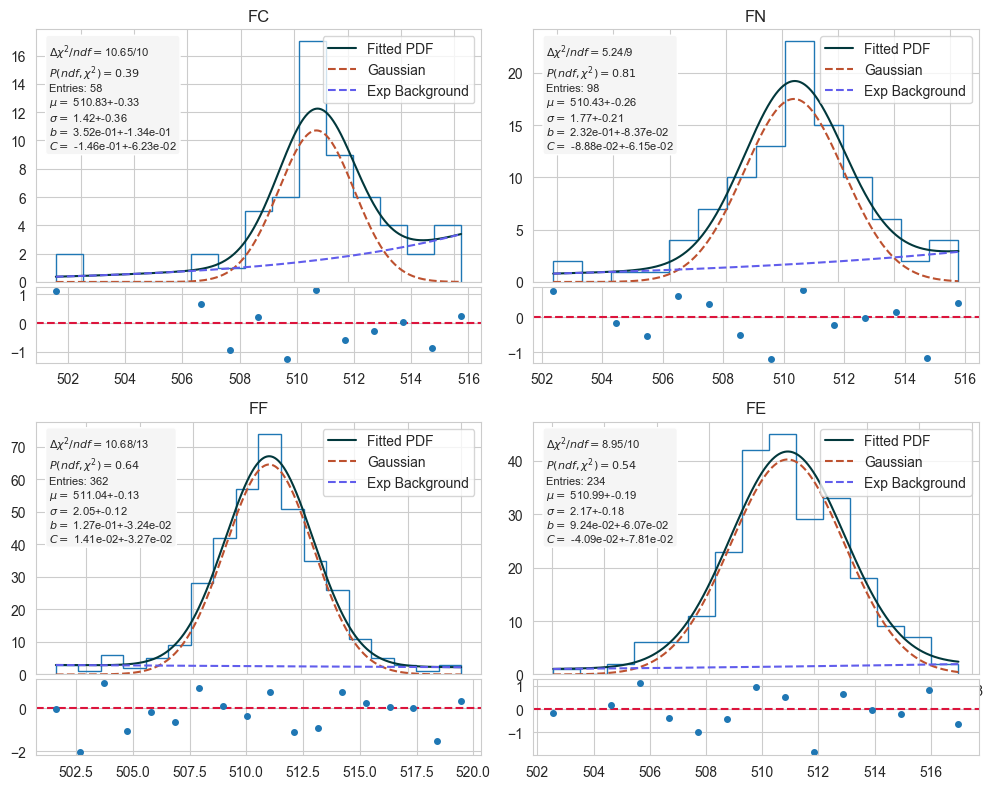

In [9]:
FC_1600, FC_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FC)
CE_1600, CE_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(CE)
NC_1600, NC_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(NC)
FN_1600, FN_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FN)
NE_1600, NE_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(NE)
FF_1600, FF_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FF)
CC_1600, CC_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(CC)
EE_1600, EE_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(EE)
NN_1600, NN_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(NN)
FE_1600, FE_1022 = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FE)

FC_1600NTD, FC_1022NTD = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FC_NTD)
FN_1600NTD, FN_1022NTD = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FN_NTD)
FF_1600NTD, FF_1022NTD = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FF_NTD)
FE_1600NTD, FE_1022NTD = M3DE511Sort.PrimarySecondarySplitDoubleEscape(FE_NTD)

FC_initial_1022 = [511, 2.3, 0.11, 6.89713150e-03]
CE_initial_1022 = [511, 2.3, 0.11, 6.89713150e-03]
NC_initial_1022 = [511, 2.3, 0.11, 6.89713150e-03]
FN_initial_1022 = [511, 2.3, 0.11, 6.89713150e-03]
NE_initial_1022 = [511, 2.3, 0.11, 6.89713150e-03]
FF_initial_1022 = [511, 2.3, 0.11, 6.89713150e-03]
EE_initial_1022= [511, 2.3, 0.11, 6.89713150e-03]
NN_initial_1022= [511, 2.3, 0.11, 6.89713150e-03]
FE_initial_1022= [511, 2.3, 0.11, 6.89713150e-03]
CC_initial_1022= [511, 2.3, 0.11, 6.89713150e-03]

FE_initial_1022NTD= [511, 2.3, 0.11, 6.89713150e-03]
FN_initial_1022NTD = [511, 2.3, 0.11, 6.89713150e-03]


hist_data = [FC_1022, CE_1022, NC_1022, FN_1022, NE_1022, FF_1022, EE_1022, NN_1022, FE_1022, CC_1022]
initial_parms = [FC_initial_1022, CE_initial_1022, NC_initial_1022, FN_initial_1022, NE_initial_1022, FF_initial_1022, EE_initial_1022, NN_initial_1022, FE_initial_1022, CC_initial_1022]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

df = M3DE511Sort.NormGaussianExpMinimizerTopology(hist_data, topologies, initial_parms, 5, 2, 10, 15)

hist_dataNTD = [FC_1022NTD, FN_1022NTD, FF_1022NTD, FE_1022NTD]
initial_parmsNTD = [FC_initial_1022, FN_initial_1022NTD, FF_initial_1022, FE_initial_1022NTD]
topologiesNTD = ['FC', 'FN', 'FF','FE']

dfNTD = M3DE511Sort.NormGaussianExpMinimizerTopology(hist_dataNTD, topologiesNTD, initial_parmsNTD, 2, 2, 10, 8)

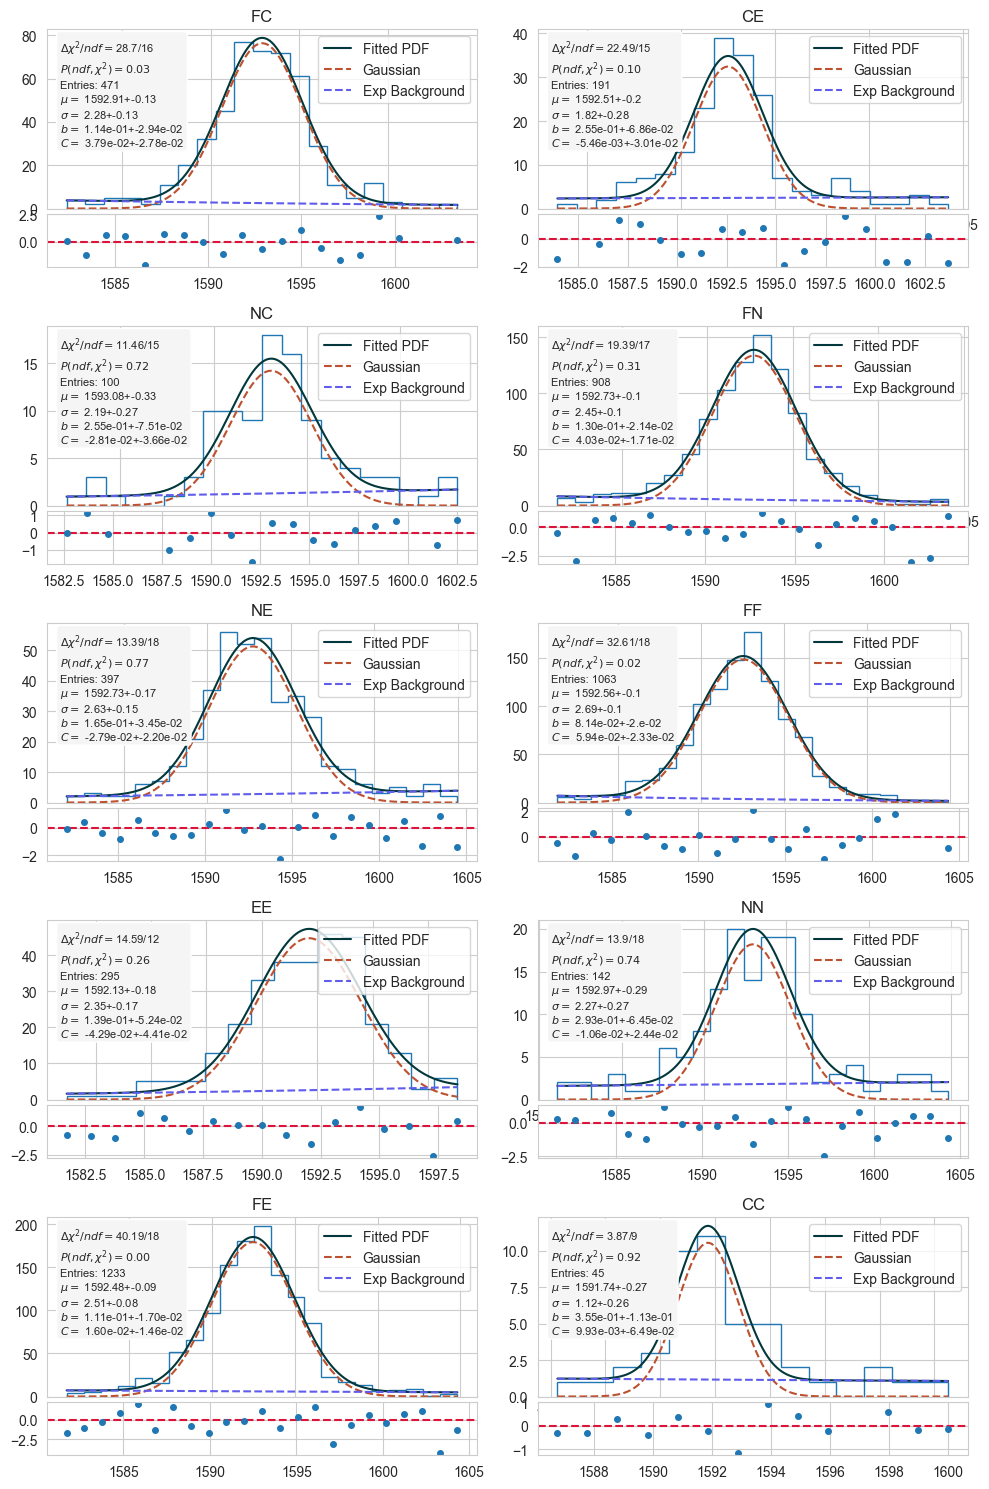

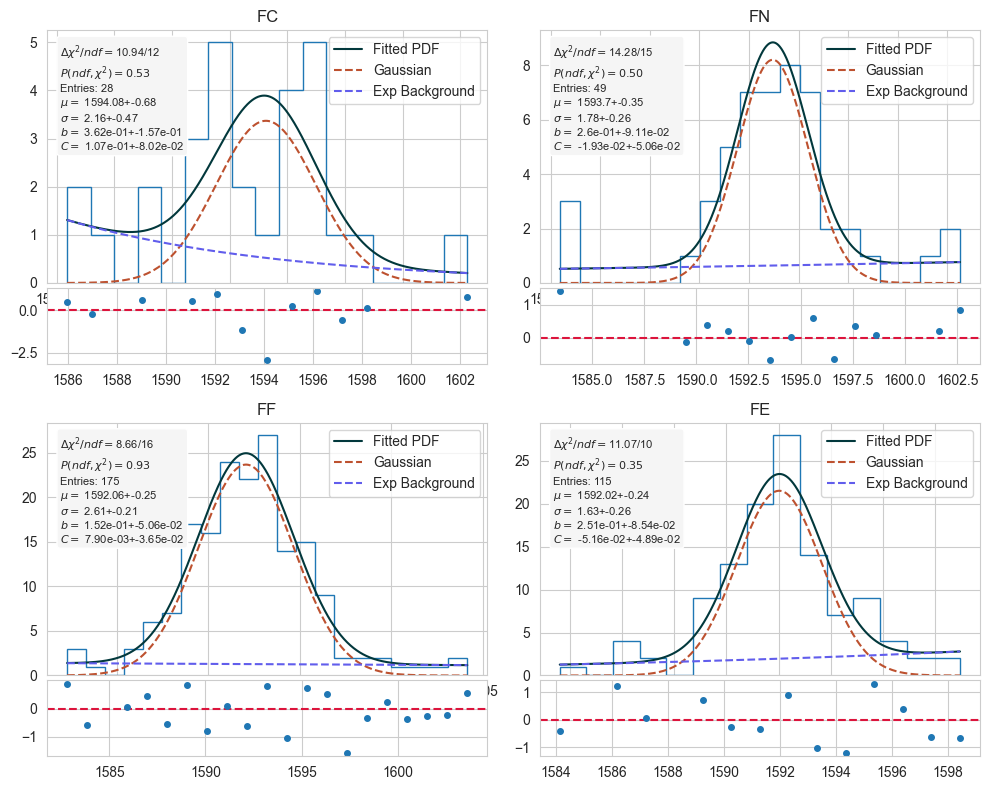

In [23]:
FC_1600_cut = [i for i in FC_1600 if  1581 < i < 1605]
CE_1600_cut = [i for i in CE_1600 if  1581 < i < 1605]
NC_1600_cut = [i for i in NC_1600 if  1581 < i < 1605]
FN_1600_cut = [i for i in FN_1600 if  1581 < i < 1605]
NE_1600_cut = [i for i in NE_1600 if  1581 < i < 1605]
FF_1600_cut = [i for i in FF_1600 if  1581 < i < 1605]
CC_1600_cut = [i for i in CC_1600 if  1581 < i < 1605]
EE_1600_cut = [i for i in EE_1600 if  1581 < i < 1605]
NN_1600_cut = [i for i in NN_1600 if  1581 < i < 1605]
FE_1600_cut = [i for i in FE_1600 if  1581 < i < 1605]

FC_1600_cutNTD = [i for i in FC_1600NTD if  1581 < i < 1605]
FE_1600_cutNTD = [i for i in FE_1600NTD if  1581 < i < 1605]
FF_1600_cutNTD = [i for i in FF_1600NTD if  1581 < i < 1605]
FN_1600_cutNTD = [i for i in FN_1600NTD if  1581 < i < 1605]

FC_initial_1600 = [1593, 2.3, 0.11, 6.89713150e-03]
CE_initial_1600 = [1593, 2.3, 0.11, 6.89713150e-03]
NC_initial_1600 = [1593, 2.3, 0.11, 6.89713150e-03]
FN_initial_1600 = [1593, 2.3, 0.11, 6.89713150e-03]
NE_initial_1600 = [1593, 2.3, 0.11, 6.89713150e-03]
FF_initial_1600 = [1593, 2.3, 0.11, 6.89713150e-03]
EE_initial_1600= [1593, 2.3, 0.11, 6.89713150e-03]
NN_initial_1600= [1593, 2.3, 0.11, 6.89713150e-03]
FE_initial_1600= [1593, 2.3, 0.11, 6.89713150e-03]
CC_initial_1600= [1593, 2.3, 0.11, 6.89713150e-03]

FC_initial_1600NTD= [1593, 2.3, 0.11, 6.89713150e-03]
FE_initial_1600NTD= [1593, 2.3, 0.11, 6.89713150e-03]


hist_data = [FC_1600_cut, CE_1600_cut, NC_1600_cut, FN_1600_cut, NE_1600_cut, FF_1600_cut, EE_1600_cut, NN_1600_cut, FE_1600_cut, CC_1600_cut]
initial_parms = [FC_initial_1600, CE_initial_1600, NC_initial_1600, FN_initial_1600, NE_initial_1600, FF_initial_1600, EE_initial_1600, NN_initial_1600, FE_initial_1600, CC_initial_1600]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

df = M3DE511Sort.NormGaussianExpMinimizerTopology(hist_data, topologies, initial_parms, 5, 2, 10, 15)

hist_dataNTD = [FC_1600_cutNTD, FN_1600_cutNTD, FF_1600_cutNTD, FE_1600_cutNTD]
initial_parmsNTD = [FC_initial_1600NTD, FN_initial_1600, FF_initial_1600, FE_initial_1600NTD]
topologiesNTD = ['FC', 'FN', 'FF','FE']

dfNTD = M3DE511Sort.NormGaussianExpMinimizerTopology(hist_dataNTD, topologiesNTD, initial_parmsNTD, 2, 2, 10, 8)

In [24]:
mean_bias, sigma, meanerr, sigmaerr = M3DE511Sort.ExpectedVals(reducedDoubleEscape, reducedDoubleEscape)

In [30]:
predictions =  df['Sigmas']
expected = [nonNTDsigma] * len(predictions)
rmse(predictions, expected)

np.float64(0.52388968126688)

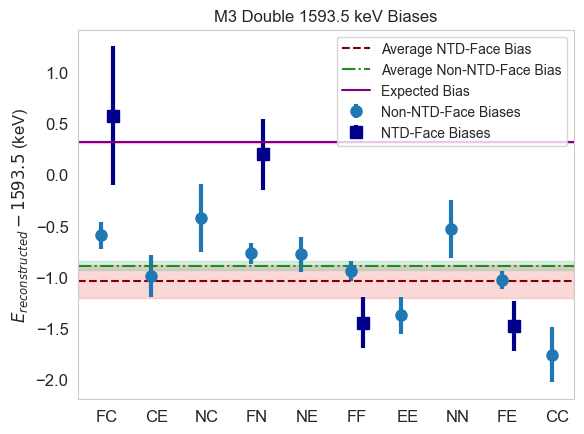

In [26]:
fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.12, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.12, 0.0) + ax.transData

ax.errorbar(topologies, df['Means']-1593.5, yerr=df['Meanserr'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Biases')
ax.errorbar(topologiesNTD, dfNTD['Means']-1593.5, yerr=dfNTD['Meanserr'], transform=trans2,fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD-Face Biases')

ax.axhspan(NTDmu-1593.5-NTDmu_err, NTDmu-1593.5+NTDmu_err, color='lightcoral', alpha=0.3)
ax.axhline(NTDmu-1593.5, color='maroon', linestyle='--', label='Average NTD-Face Bias')

ax.axhspan(nonNTDmu-1593.5-nonNTDmu_err, nonNTDmu-1593.5+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDmu-1593.5, color='forestgreen', linestyle='-.', label='Average Non-NTD-Face Bias')

ax.set_ylabel(r'$E_{reconstructed}-1593.5$ (keV)', fontsize=12)

ax.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
ax.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias')

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 1593.5 keV Biases')
ax.legend(fontsize=10, loc = 'upper right')

Text(0.5, 1.0, 'M3 Double 1563.5 keV Std Dev')

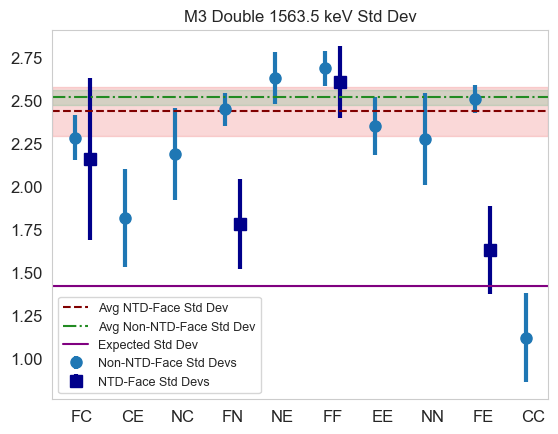

In [36]:
fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.15, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.15, 0.0) + ax.transData

ax.errorbar(topologies, df['Sigmas'], yerr=df['Sigmaserr'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Std Devs')
ax.errorbar(topologiesNTD, dfNTD['Sigmas'], yerr=dfNTD['Sigmaserr'], transform=trans2,fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD-Face Std Devs')

ax.axhspan(NTDsigma-NTDsigma_err, NTDsigma+NTDsigma_err, color='lightcoral', alpha=0.3)
ax.axhline(NTDsigma, color='maroon', linestyle='--', label='Avg NTD-Face Std Dev')

ax.axhspan(nonNTDsigma-nonNTDsigma_err, nonNTDsigma+nonNTDsigma_err, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Avg Non-NTD-Face Std Dev')

ax.legend(fontsize=10, loc='upper left')

ax.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
ax.axhline(sigma, color='purple', linestyle='-', label='Expected Std Dev')

ax.legend(loc='lower left', fontsize=9)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 1563.5 keV Std Dev')

In [21]:
predictions = dfNTD['Sigmas']
expected = [NTDsigma] * len(predictions)
rmse(predictions, expected)

np.float64(0.42658810375237616)

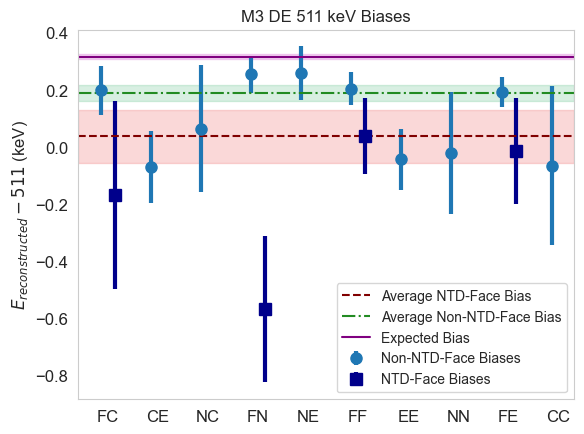

In [11]:
fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.14, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.14, 0.0) + ax.transData

ax.errorbar(topologies, df['Means']-511, yerr=df['Meanserr'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Biases')
ax.errorbar(topologiesNTD, dfNTD['Means']-511, yerr=dfNTD['Meanserr'], transform=trans2,fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD-Face Biases')

ax.axhspan(NTDmu-511-NTDmu_err, NTDmu-511+NTDmu_err, color='lightcoral', alpha=0.3)
ax.axhline(NTDmu-511, color='maroon', linestyle='--', label='Average NTD-Face Bias')

ax.axhspan(nonNTDmu-511-nonNTDmu_err, nonNTDmu-511+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDmu-511, color='forestgreen', linestyle='-.', label='Average Non-NTD-Face Bias')

ax.legend(fontsize=10, loc='lower right')

ax.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
ax.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias')

ax.set_ylabel(r'$E_{reconstructed}-511$ (keV)', fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 DE 511 keV Biases')
plt.legend()

Text(0.5, 1.0, 'M3 DE 511 keV Std Devs')

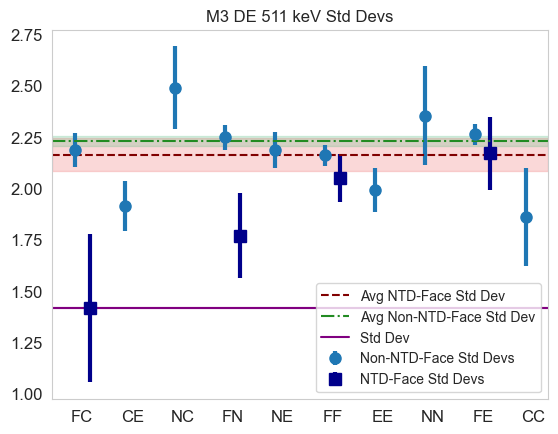

In [13]:
fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.15, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.15, 0.0) + ax.transData

ax.errorbar(topologies, df['Sigmas'], yerr=df['Sigmaserr'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Std Devs')
ax.errorbar(topologiesNTD, dfNTD['Sigmas'], yerr=dfNTD['Sigmaserr'], transform=trans2,fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD-Face Std Devs')

ax.axhspan(NTDsigma-NTDsigma_err, NTDsigma+NTDsigma_err, color='lightcoral', alpha=0.3)
ax.axhline(NTDsigma, color='maroon', linestyle='--', label='Avg NTD-Face Std Dev')

ax.axhspan(nonNTDsigma-nonNTDsigma_err, nonNTDsigma+nonNTDsigma_err, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Avg Non-NTD-Face Std Dev')

ax.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
ax.axhline(sigma, color='purple', linestyle='-', label='Std Dev')

ax.legend(fontsize=10, loc='lower right')

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 DE 511 keV Std Devs')